# 05: Modelling Pipeline (Regression on USA Real Estate)

This notebook implements a complete **regression modelling pipeline** on the
cleaned and feature-engineered USA real estate dataset. It follows an
MLOps-oriented structure:

- Deterministic data loading and splitting.
- Shared preprocessing with `ColumnTransformer`.
- Multiple baseline and advanced models.
- **Bayesian hyperparameter optimisation** for strong candidates.
- Model selection based on cross-validated **RMSE**.
- Final evaluation on a held-out test set using MAE, RMSE and R².
- Learning curve analysis for underfitting vs overfitting diagnosis.
- Persisting the best pipeline and metrics to Google Drive.

---
# 1 Import Libraries and Define Global Configuration

We now import all required libraries:

- **Core**: `numpy`, `pandas`
- **Visualisation**: `matplotlib`, `seaborn`
- **Model building**: scikit-learn regressors, pipelines, metrics
- **Bayesian optimisation**: `BayesSearchCV` and search spaces
- **Persistence**: `joblib` for saving the final model

We also define:

- The target column (`price`)
- The random seed
- The train-test split ratio
- File paths for saving models and metrics


In [ ]:
"""Global configuration, imports, and paths for DOAA regression modelling.

This module:
    * Installs and configures dependencies (for example, scikit-optimize).
    * Sets up Google Drive integration in Colab.
    * Centralises global constants such as the target column, random seed,
      cross-validation settings, and model output paths.

These configurations are used across the full regression workflow, including
data preprocessing, model training, hyperparameter tuning, and evaluation.
"""

# Install scikit-optimize (required for BayesSearchCV in Colab notebooks).
!pip install -q scikit-optimize  # noqa: E402
!pip install xgboost lightgbm catboost

import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns

from typing import Dict, List, Tuple, Optional
from __future__ import annotations
from datetime import datetime
from google.colab import drive  # type: ignore
from matplotlib import pyplot as plt
from skopt import BayesSearchCV
from __future__ import annotations
from skopt.space import Integer, Real
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.base import RegressorMixin
from sklearn.impute import SimpleImputer
from joblib import Parallel  # noqa: F401
from sklearn.linear_model import Lasso, LinearRegression, Ridge, ElasticNet, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from typing import Dict
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
from catboost import CatBoostRegressor
from sklearn.base import clone
from skopt.space import Integer, Real, Categorical

# ---------------------------------------------------------------------------
# Environment setup (Colab + plotting style)
# ---------------------------------------------------------------------------
drive.mount("/content/drive")

sns.set(style="whitegrid")

# ---------------------------------------------------------------------------
# Global configuration constants
# ---------------------------------------------------------------------------
TARGET_COL: str = "price"
RANDOM_STATE: int = 42
N_SPLITS: int = 5
TEST_SIZE: float = 0.2

MODEL_DIR: str = "/content/drive/MyDrive/Colab Notebooks/DOAA/models"
METRICS_PATH: str = os.path.join(MODEL_DIR, "best_model_metrics.csv")
BEST_MODEL_PATH: str = os.path.join(MODEL_DIR, "best_regressor.joblib")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 17.9 MB/s eta 0:00:00
Mounted at /content/drive


The modelling environment is now configured with a consistent random seed and
standard paths for saving artefacts. All subsequent steps will reuse these
constants to keep the workflow reproducible and MLOps-aligned.

---
# 2 Load Feature-Engineered Dataset

We now load the **feature-engineered** USA real estate dataset that was
produced in earlier stages (cleaning + feature engineering). This dataset
should:

- Contain `price` as the numeric target.
- Exclude dropped raw columns (e.g. `street`, `zip_code` if removed).
- Include engineered numeric features that have already passed EDA checks.

Update the CSV path below if your filename or folder structure differs.

In [ ]:
"""Load the engineered dataset from Parquet for regression modelling.

This module:
    * Loads the final processed dataset stored in Google Drive.
    * Validates the presence of the target column.
    * Prints the dataset shape for a quick sanity check.
"""

def load_engineered_parquet(path: str, target_col: str) -> pd.DataFrame:
    """Load a Parquet dataset and verify the target column exists.

    Args:
        path: Absolute path to the Parquet file.
        target_col: Name of the required target column.

    Returns:
        A pandas DataFrame containing the dataset.

    Raises:
        FileNotFoundError: If the Parquet file cannot be located.
        KeyError: If the target column is not present in the dataset.
    """
    try:
        df_loaded = pd.read_parquet(path)
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"Dataset file not found at path: {path!r}"
        ) from exc

    if target_col not in df_loaded.columns:
        raise KeyError(
            f"Target column '{target_col}' not found in dataset. "
            f"Available columns: {list(df_loaded.columns)}"
        )

    print(f"Dataset loaded successfully. Shape: {df_loaded.shape}")
    return df_loaded


# ---------------------------------------------------------------------------
# Execute: Load Engineered Dataset
# ---------------------------------------------------------------------------
ENGINEERED_CSV_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/"
    "data_processed/final_dataset_20251116_0720.parquet"
)

df = load_engineered_parquet(
    path=ENGINEERED_CSV_PATH,
    target_col=TARGET_COL,
)

df.head()

Dataset loaded successfully. Shape: (2224841, 9)


,acre_lot_log1p,bath_log1p,city_listing_count,house_size,state_listing_count,status_is_ready_to_build,status_is_sold,total_rooms,price
0,0.113329,1.098612,2,920.0,3126,0,0,5,105000.0
1,0.076961,1.098612,2,1527.0,3126,0,0,6,80000.0
2,0.139762,0.693147,17,748.0,3126,0,0,3,67000.0
3,0.095310,1.098612,81,1800.0,3126,0,0,6,145000.0
4,0.048790,1.098612,64,2514.0,3126,0,0,8,65000.0


The printed shape and preview confirm that the feature-engineered dataset has
been loaded successfully and that the `price` column is present. We can now
proceed to identify which remaining columns should be treated as numeric and
which as categorical features for the modelling pipeline.

---
# 3. Feature Typing & Train-Test Split

---
# 3.1 Infer Numeric and Categorical Feature Columns

To build a robust preprocessing pipeline, we separate the columns into:

- **Numeric features**: direct numeric inputs to the model.
- **Categorical features**: non-numeric columns that require encoding.

The helper function below infers these lists by:

- Dropping the target column.
- Selecting numeric dtypes as numeric features.
- Treating the remaining non-numeric, non-ID-like columns as categorical.

In [ ]:
"""Feature type inference with structured DataFrame output.

This module infers numeric and categorical feature columns (excluding the
target) and returns a neatly formatted DataFrame summarising each feature’s
metadata, such as dtype, missingness, and uniqueness.
"""


def infer_feature_metadata(
    df_in: pd.DataFrame,
    target_col: str,
) -> pd.DataFrame:
    """Infer feature metadata for modelling, excluding the target column.

    The function:
        * Removes the target column.
        * Infers feature type (`numeric` or `categorical`).
        * Excludes ID-like columns (prefix "id").
        * Computes descriptive metadata per column.

    Args:
        df_in: Dataset containing features and target.
        target_col: Name of the target column to exclude.

    Returns:
        A pandas DataFrame with columns:
            - feature: Name of the feature column.
            - feature_type: "numeric" or "categorical".
            - dtype: Pandas dtype of the column.
            - n_unique: Number of unique non-null values.
            - n_missing: Number of missing entries.
            - pct_missing: Percentage of missing entries.
    """
    feature_df = df_in.drop(columns=[target_col])

    global numeric_cols

    numeric_cols = (
        feature_df.select_dtypes(include=[np.number]).columns.tolist()
    )

    global categorical_cols

    categorical_cols = [
        col
        for col in feature_df.columns
        if col not in numeric_cols and not col.lower().startswith("id")
    ]

    records = []

    for col in feature_df.columns:
        if col in numeric_cols:
            ftype = "numeric"
        elif col in categorical_cols:
            ftype = "categorical"
        else:
            # Skip ID-like or unidentified columns
            continue

        series = feature_df[col]

        n_missing = series.isna().sum()
        pct_missing = (
            (n_missing / len(series)) * 100 if len(series) > 0 else 0
        )

        records.append(
            {
                "feature": col,
                "feature_type": ftype,
                "dtype": str(series.dtype),
                "n_unique": series.nunique(dropna=True),
                "n_missing": n_missing,
                "pct_missing": round(pct_missing, 3),
            }
        )

    meta_df = pd.DataFrame(records)
    return meta_df.sort_values("feature_type").reset_index(drop=True)


# ---------------------------------------------------------------------------
# Execute and display
# ---------------------------------------------------------------------------
feature_metadata_df = infer_feature_metadata(
    df_in=df,
    target_col=TARGET_COL,
)

feature_metadata_df

,feature,feature_type,dtype,n_unique,n_missing,pct_missing
0,acre_lot_log1p,numeric,float64,12128,0,0.0
1,bath_log1p,numeric,float64,4,0,0.0
2,city_listing_count,numeric,int64,1133,0,0.0
3,house_size,numeric,float64,17934,0,0.0
4,state_listing_count,numeric,int64,56,0,0.0
5,status_is_ready_to_build,numeric,int64,2,0,0.0
6,status_is_sold,numeric,int64,2,0,0.0
7,total_rooms,numeric,int64,8,0,0.0


The lists displayed above summarise the modelling feature space:

- `numeric_features` will feed into the numeric preprocessing branch.
- `categorical_features` will be handled by the categorical branch
  (imputation + one-hot encoding).

This explicit separation supports a clean `ColumnTransformer` definition and
reduces the risk of accidentally leaking target information.

---
## 3.2 Train-Test Split

We now split the dataset into:

- **Training set**: used for cross-validation and hyperparameter tuning.
- **Test set**: held out and used only once at the end to approximate
  real-world performance.

Formally, if $D$ is the full dataset:

- $D_\text{train} \cup D_\text{test} = D$
- $D_\text{train} \cap D_\text{test} = \emptyset$

In [ ]:
"""Train/test split with structured DataFrame summary."""


def split_features_and_target(
    df_in: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
    target_col: str,
    test_size: float,
    random_state: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Split dataset into train/test sets for modelling.

    Args:
        df_in: Full dataset including features and target.
        numeric_cols: List of numeric feature column names.
        categorical_cols: List of categorical feature column names.
        target_col: Target column name.
        test_size: Proportion of test split.
        random_state: Seed for reproducibility.

    Returns:
        X_train, X_test, y_train, y_test in that order.
    """
    X = df_in[numeric_cols + categorical_cols].copy()
    y = df_in[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    return X_train, X_test, y_train, y_test


def summarise_train_test_shapes(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> pd.DataFrame:
    """Return a structured summary of train/test shapes.

    Args:
        X_train: Training feature matrix.
        X_test: Testing feature matrix.
        y_train: Training target vector.
        y_test: Testing target vector.

    Returns:
        A DataFrame summarising the size of each split.
    """
    summary = pd.DataFrame(
        [
            {
                "set": "X_train",
                "n_rows": X_train.shape[0],
                "n_cols": X_train.shape[1],
            },
            {
                "set": "X_test",
                "n_rows": X_test.shape[0],
                "n_cols": X_test.shape[1],
            },
            {
                "set": "y_train",
                "n_rows": y_train.shape[0],
                "n_cols": 1,
            },
            {
                "set": "y_test",
                "n_rows": y_test.shape[0],
                "n_cols": 1,
            },
        ]
    )

    return summary


# ---------------------------------------------------------------------------
# Execute: Split + Summary
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = split_features_and_target(
    df_in=df,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=TARGET_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

split_summary_df = summarise_train_test_shapes(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

split_summary_df

,set,n_rows,n_cols
0,X_train,1779872,8
1,X_test,444969,8
2,y_train,1779872,1
3,y_test,444969,1


The logged shapes confirm an 80/20 train–test split (based on `TEST_SIZE`).
All model selection, cross-validation and Bayesian optimisation steps will now
use only the training data (`X_train`, `y_train`), preserving the test set
for final evaluation.

---
# 4. Preprocessing & Model Candidates

---
## 4.1 Preprocessing Pipeline with ColumnTransformer

To avoid data leakage and ensure consistency between training and inference,
we define a `ColumnTransformer` that applies:

- For numeric features:
  - `SimpleImputer(strategy="median")`
  - `StandardScaler`
- For categorical features:
  - `SimpleImputer(strategy="most_frequent")`
  - `OneHotEncoder(handle_unknown="ignore")`

This transformer will be plugged into each regression model as part of a
unified `Pipeline`.

In [ ]:
"""Preprocessing pipelines for numeric and categorical features.

This module defines:
    * Numeric transformer: median imputation + standard scaling.
    * Categorical transformer: most-frequent imputation + one-hot encoding.
    * Combined ColumnTransformer for unified preprocessing.

These transformers are used in downstream modelling pipelines
(Random Forest, Gradient Boosting, Linear Models, BayesSearchCV, etc.).
"""


def build_preprocessor(
    numeric_cols: List[str],
    categorical_cols: List[str],
) -> ColumnTransformer:
    """Create a unified preprocessing pipeline for modelling.

    Args:
        numeric_cols: List of numeric feature names.
        categorical_cols: List of categorical feature names.

    Returns:
        A fitted/unfitted ColumnTransformer that:
            - Imputes + scales numeric features.
            - Imputes + encodes categorical features.
    """
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )

    return preprocessor


# ---------------------------------------------------------------------------
# Execute: Build Preprocessor
# ---------------------------------------------------------------------------
preprocessor = build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['acre_lot_log1p', 'bath_log1p',
                                  'city_listing_count', 'house_size',
                                  'state_listing_count',
                                  'status_is_ready_to_build', 'status_is_sold',
                                  'total_rooms']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])

The `preprocessor` object now encapsulates all transformation logic required
to convert the raw input features into a fully numeric, scaled design matrix.
Because it is part of the final `Pipeline`, this logic is consistently applied
during training, cross-validation and inference.

---
## 4.2 Define Baseline and Candidate Regression Models

We define several regression models, all wrapped with the shared
preprocessing pipeline:

- `DummyRegressor` (median): baseline for comparison.
- `LinearRegression`: ordinary least squares.
- `Ridge`: L2-regularised linear regression.
- `Lasso`: L1-regularised linear regression.
- `RandomForestRegressor`: ensemble of decision trees.
- `GradientBoostingRegressor`: gradient-based tree ensemble.

Each model is constructed via a helper function that builds
`Pipeline(preprocess → model)`.

In [ ]:
"""Pipeline construction utilities and model registry for regression.

This module:
    * Builds a unified preprocessing → model pipeline.
    * Registers EVERY major regression model EXCEPT SVMs:
        - Linear family
        - Tree ensembles
        - Gradient boosting (sklearn / XGB / LGBM / CatBoost)
        - kNN
        - MLP
        - Decision Trees
        - ExtraTrees
        - AdaBoost
        - HistGradientBoosting
"""

# ==========================================================
# Pipeline builder
# ==========================================================
def make_pipeline(model: RegressorMixin) -> Pipeline:
    """Create a modelling pipeline with shared preprocessing."""
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )


# ==========================================================
# MODEL REGISTRY (SVMs REMOVED)
# ==========================================================

model_candidates: Dict[str, Pipeline] = {
    # ------------------- Baselines -------------------
    "dummy_median": make_pipeline(
        DummyRegressor(strategy="median")
    ),
    "linear": make_pipeline(
        LinearRegression()
    ),
    "ridge": make_pipeline(
        Ridge(random_state=RANDOM_STATE)
    ),
    "lasso": make_pipeline(
        Lasso(random_state=RANDOM_STATE)
    ),
    "elastic_net": make_pipeline(
        ElasticNet(random_state=RANDOM_STATE)
    ),
    "huber": make_pipeline(
        HuberRegressor()
    ),

    # ------------------- Tree-based -------------------
    "dt": make_pipeline(
        DecisionTreeRegressor(random_state=RANDOM_STATE)
    ),
    "rf": make_pipeline(
        RandomForestRegressor(
            n_estimators=500,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "extra_trees": make_pipeline(
        ExtraTreesRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),

    # ------------------- Boosting (sklearn) -------------------
    "gbr": make_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
    "hist_gbr": make_pipeline(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
    "ada": make_pipeline(
        AdaBoostRegressor(random_state=RANDOM_STATE)
    ),

    # ------------------- External Boosting (XGB, LGBM, CatBoost) -------------------
    "xgb": make_pipeline(
        XGBRegressor(
            n_estimators=800,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    "lgbm": make_pipeline(
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
        )
    ),
    "catboost": make_pipeline(
        CatBoostRegressor(
            depth=8,
            learning_rate=0.05,
            n_estimators=800,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
        )
    ),

    # ------------------- Nearest neighbours -------------------
    "knn": make_pipeline(
        KNeighborsRegressor(
            n_neighbors=5,
            weights="distance",
        )
    ),
}

# Quick sanity check
list(model_candidates.keys())

['dummy_median',
 'linear',
 'ridge',
 'lasso',
 'elastic_net',
 'huber',
 'dt',
 'rf',
 'extra_trees',
 'gbr',
 'hist_gbr',
 'ada',
 'xgb',
 'lgbm',
 'catboost',
 'knn']

The list printed above confirms that our candidate pool contains both simple
linear models and more expressive tree-based ensembles. All of them use the
shared `preprocessor`, which keeps the feature handling logic centralised and
leakage-safe.

---
# 5. Cross-Validation & Bayesian Tuning

---
## 5.1 Cross-Validation Configuration and Initial Model Benchmark

We now define:

- A `KFold` cross-validator with `K = 5`, shuffling enabled.
- A `scoring` dictionary mapping metric names to scikit-learn scorers.

For each candidate model, we run cross-validation on the training set and
compute:

- Mean and standard deviation of MAE.
- Mean and standard deviation of RMSE.
- Mean and standard deviation of R².

Note: scikit-learn returns negative values for loss-based metrics, so we
negate them to obtain positive MAE and RMSE values.

In [ ]:
"""Cross-validation evaluation for baseline and advanced regression models.

This module:
    * Defines a scoring dictionary for MAE, RMSE, and R².
    * Configures a shuffled KFold cross-validator.
    * Runs cross-validation for each candidate model pipeline with
      controlled parallelism to avoid memory issues.
    * Handles a wide range of models, from simple linear baselines to
      advanced tree ensembles and gradient boosting (e.g. RF, HistGBR,
      XGBoost, LightGBM, CatBoost), as long as they are registered in
      `model_candidates`.
    * Aggregates results into a neatly formatted DataFrame.
"""


SCORING: Dict[str, str] = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def evaluate_models_cv(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    models: Dict[str, Pipeline],
    cv_strategy: KFold,
    scoring: Dict[str, str],
    n_jobs_cv: int = 1,
) -> pd.DataFrame:
    """Run cross-validation for a dictionary of model pipelines.

    For each model, this function:
        * Executes cross-validation using the provided strategy and scoring.
        * Uses a configurable `n_jobs_cv` to control parallelism and avoid
          out-of-memory issues on constrained environments (for example,
          Google Colab).
        * Converts MAE and RMSE from negative (sklearn convention) to
          positive values.
        * Computes mean and standard deviation for each metric.
        * Skips models that raise errors during cross-validation, logging
          a warning instead of failing the entire evaluation loop.

    Args:
        X_train: Training feature matrix.
        y_train: Training target vector.
        models: Dictionary mapping model names to sklearn Pipelines.
        cv_strategy: Cross-validation strategy (for example, KFold instance).
        scoring: Dictionary of scoring metrics compatible with sklearn.
        n_jobs_cv: Number of parallel jobs for `cross_validate`. Use 1 to
            disable parallelism and reduce memory usage.

    Returns:
        A DataFrame summarising, for each successfully evaluated model:
            - model
            - mae_mean, mae_std
            - rmse_mean, rmse_std
            - r2_mean, r2_std

        The resulting DataFrame is sorted by `rmse_mean` in ascending order.
    """
    results: List[Dict[str, float | str]] = []

    for name, pipe in models.items():
        print(f"[INFO] Running cross-validation for: {name}")
        try:
            cv_res = cross_validate(
                pipe,
                X_train,
                y_train,
                cv=cv_strategy,
                scoring=scoring,
                n_jobs=n_jobs_cv,
                return_train_score=False,
            )
        except Exception as exc:
            print(
                f"[WARN] Skipping model '{name}' due to error during CV: "
                f"{type(exc).__name__}: {exc}"
            )
            continue

        mae_scores = -cv_res["test_mae"]
        rmse_scores = -cv_res["test_rmse"]
        r2_scores = cv_res["test_r2"]

        results.append(
            {
                "model": name,
                "mae_mean": float(mae_scores.mean()),
                "mae_std": float(mae_scores.std()),
                "rmse_mean": float(rmse_scores.mean()),
                "rmse_std": float(rmse_scores.std()),
                "r2_mean": float(r2_scores.mean()),
                "r2_std": float(r2_scores.std()),
            }
        )

    cv_summary = pd.DataFrame(results).sort_values(
        "rmse_mean",
        ascending=True,
    )

    return cv_summary.reset_index(drop=True)


# ---------------------------------------------------------------------------
# Execute: Cross-validation and summary table
# ---------------------------------------------------------------------------
cv_summary = evaluate_models_cv(
    X_train=X_train,
    y_train=y_train,
    models=model_candidates,
    cv_strategy=cv,
    scoring=SCORING,
    n_jobs_cv=1,
)

cv_summary

[INFO] Running cross-validation for: dummy_median
[INFO] Running cross-validation for: linear
[INFO] Running cross-validation for: ridge
[INFO] Running cross-validation for: lasso
[INFO] Running cross-validation for: elastic_net
[INFO] Running cross-validation for: huber
[INFO] Running cross-validation for: dt
[INFO] Running cross-validation for: rf
[INFO] Running cross-validation for: extra_trees
[INFO] Running cross-validation for: gbr
[INFO] Running cross-validation for: hist_gbr
[INFO] Running cross-validation for: ada
[INFO] Running cross-validation for: xgb
[INFO] Running cross-validation for: lgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 1423897, number of used features: 8
[LightGBM] [Info] Start training fr

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423897, number of used features: 8
[LightGBM] [Info] Start training from score 403500.551911


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423898, number of used features: 8
[LightGBM] [Info] Start training from score 403445.155355


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423898, number of used features: 8
[LightGBM] [Info] Start training from score 403426.805499


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] Running cross-validation for: catboost
[INFO] Running cross-validation for: knn


,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,rf,114511.919981,133.286423,182227.397038,276.171300,0.665024,0.001022
1,xgb,126857.573653,356.879178,185970.815991,505.614807,0.651119,0.001705
2,extra_trees,120152.831665,172.285823,192469.662864,212.606312,0.626310,0.001127
3,lgbm,138028.856421,207.360191,197700.401614,330.886181,0.605723,0.001205
4,catboost,146672.963187,286.894037,207634.163662,419.434547,0.565105,0.001652
5,hist_gbr,153806.904134,316.219601,215311.589507,431.649998,0.532348,0.001979
6,knn,142148.192838,155.435080,221082.674251,234.343257,0.506945,0.000860
7,dt,141259.329045,345.334414,240006.702674,459.645898,0.418920,0.002865
8,gbr,178091.283995,361.308877,241498.280497,267.722696,0.411679,0.001158
9,ada,227668.232709,3734.516024,282286.596433,2456.654535,0.196107,0.013905


The cross-validation summary ranks all candidate models by **mean RMSE**.
The `dummy_median` baseline indicates how well a naïve “always predict
median price” strategy performs, while the other models demonstrate the
added value of linear and tree-based approaches.

We will use this table to select the strongest tree models for Bayesian
hyperparameter optimisation.

---
## 5.2 Bayesian Hyperparameter Optimisation for Tree Models

Tree-based models such as **Random Forest** and **Gradient Boosting** often
benefit considerably from tuning depth, number of estimators, learning rate
and related hyperparameters.

Instead of grid search, we use **Bayesian optimisation** via `BayesSearchCV`,
which maintains a surrogate model of the validation loss and proposes
promising hyperparameter configurations in a more sample-efficient manner.

In [ ]:
"""Model selection and Random Search hyperparameter tuning for top regressors.

This script:
    * Selects the TOP-2 models from a CV summary based on RMSE.
    * Defines random search spaces for supported models in `model_candidates`,
      including:
        - Linear family (ridge, lasso, elastic_net, huber)
        - Tree-based (dt, rf, extra_trees)
        - Boosting (gbr, hist_gbr, ada, xgb, lgbm, catboost)
        - Nearest neighbours (knn)
    * For models without a search space (e.g. dummy_median, linear),
      the base pipeline is reused without tuning.
    * Runs RandomizedSearchCV on a tuning subset to control runtime.
    * Refits the best hyperparameters on the FULL training set.
    * Combines the tuned TOP-2 models into a VotingRegressor ensemble.
    * Returns tuned pipelines (including the ensemble) and a tuning summary.
"""

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.ensemble import VotingRegressor
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime


# ======================================================================
# Helper: Select top models
# ======================================================================

def get_best_from_cv_summary(cv_df: pd.DataFrame, top_n: int = 2):
    return (
        cv_df.sort_values("rmse_mean")
        .head(top_n)["model"]
        .tolist()
    )


# ======================================================================
# Helper: Tuning subset
# ======================================================================

def create_tuning_subset(X_train, y_train, max_samples=200_000, random_state=42):
    n_rows = X_train.shape[0]
    if n_rows <= max_samples:
        print(f"[INFO] Dataset has {n_rows} rows; using full data for tuning.")
        return X_train, y_train

    print(f"[INFO] Creating tuning subset: {max_samples} rows out of {n_rows}.")
    X_tune, _, y_tune, _ = train_test_split(
        X_train, y_train,
        train_size=max_samples,
        random_state=random_state,
        shuffle=True,
    )
    return X_tune, y_tune


# ======================================================================
# Helper: Per-iteration checkpoint logger for Random Search
# ======================================================================

def make_random_search_checkpoint_callback(model_name, checkpoint_dir):
    os.makedirs(checkpoint_dir, exist_ok=True)
    iter_state = {"i": 0}

    log_path = os.path.join(
        checkpoint_dir,
        f"{model_name}_tuning_log.csv",
    )

    def _callback(estimator, search_space):
        iter_state["i"] += 1
        i = iter_state["i"]
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        best_estimator = estimator.best_estimator_
        best_params = estimator.best_params_
        best_score = -estimator.best_score_

        model_path = os.path.join(
            checkpoint_dir,
            f"{model_name}_best_iter{i:03d}_{timestamp}.pkl",
        )
        joblib.dump(best_estimator, model_path)

        print(
            f"[CHECKPOINT] {model_name}: iter={i} saved → {model_path}"
        )

        record = {
            "model": model_name,
            "iteration": i,
            "timestamp": timestamp,
            "best_rmse_cv_so_far": best_score,
            "best_params_so_far": best_params,
            "checkpoint_path": model_path,
        }

        if os.path.exists(log_path):
            df_old = pd.read_csv(log_path)
            df_new = pd.concat([df_old, pd.DataFrame([record])], ignore_index=True)
        else:
            df_new = pd.DataFrame([record])

        df_new.to_csv(log_path, index=False)
        print(f"[LOG] {model_name}: updated → {log_path}")

    return _callback


# ======================================================================
# Main: RandomisedSearchCV tuning
# ======================================================================

def random_tune_top_models(
    top_models,
    model_registry,
    cv_strategy,
    random_state,
    X_train,
    y_train,
    checkpoint_dir="/content/drive/MyDrive/DOAA/random_search_checkpoints",
    max_tuning_samples=200_000,
    n_iter=30,
):

    tuned_pipelines = {}
    tuning_records = []

    # Tuning subset
    X_tune, y_tune = create_tuning_subset(
        X_train, y_train,
        max_samples=max_tuning_samples,
        random_state=random_state,
    )

    # Search spaces identical to your Bayes version
    search_spaces = {
        "ridge": {
            "model__alpha": np.logspace(-4, 1, 50),
        },
        "lasso": {
            "model__alpha": np.logspace(-4, 1, 50),
        },
        "elastic_net": {
            "model__alpha": np.logspace(-4, 1, 50),
            "model__l1_ratio": np.linspace(0, 1, 20),
        },
        "huber": {
            "model__epsilon": np.linspace(1, 5, 20),
            "model__alpha": np.logspace(-4, 0, 20),
        },
        "dt": {
            "model__max_depth": np.arange(3, 41),
            "model__min_samples_split": np.arange(2, 21),
            "model__min_samples_leaf": np.arange(1, 21),
        },
        "rf": {
            "model__n_estimators": np.arange(400, 1201),
            "model__max_depth": np.arange(6, 41),
            "model__min_samples_split": np.arange(2, 21),
            "model__min_samples_leaf": np.arange(1, 11),
            "model__max_features": np.linspace(0.3, 1.0, 20),
        },
        "extra_trees": {
            "model__n_estimators": np.arange(400, 1201),
            "model__max_depth": np.arange(6, 41),
            "model__min_samples_split": np.arange(2, 21),
            "model__min_samples_leaf": np.arange(1, 11),
            "model__max_features": np.linspace(0.3, 1.0, 20),
        },
        "gbr": {
            "model__n_estimators": np.arange(300, 1001),
            "model__learning_rate": np.logspace(-2, -0.7, 20),
            "model__max_depth": np.arange(2, 7),
            "model__subsample": np.linspace(0.6, 1.0, 20),
            "model__min_samples_split": np.arange(2, 21),
            "model__min_samples_leaf": np.arange(1, 11),
        },
        "hist_gbr": {
            "model__learning_rate": np.logspace(-2, -0.5, 20),
            "model__max_depth": np.arange(3, 17),
            "model__max_leaf_nodes": np.arange(15, 121),
            "model__min_samples_leaf": np.arange(5, 61),
            "model__l2_regularization": np.linspace(0, 1, 20),
        },
        "ada": {
            "model__n_estimators": np.arange(100, 801),
            "model__learning_rate": np.logspace(-2, 0, 20),
        },
        "xgb": {
            "model__n_estimators": np.arange(400, 1201),
            "model__max_depth": np.arange(3, 13),
            "model__learning_rate": np.logspace(-2, -0.5, 20),
            "model__subsample": np.linspace(0.6, 1.0, 20),
            "model__colsample_bytree": np.linspace(0.6, 1.0, 20),
        },
        "lgbm": {
            "model__n_estimators": np.arange(400, 1401),
            "model__num_leaves": np.arange(31, 256),
            "model__max_depth": np.arange(3, 17),
            "model__learning_rate": np.logspace(-2, -0.7, 20),
            "model__subsample": np.linspace(0.6, 1.0, 20),
            "model__colsample_bytree": np.linspace(0.6, 1.0, 20),
        },
        "catboost": {
            "model__n_estimators": np.arange(400, 1201),
            "model__depth": np.arange(4, 11),
            "model__learning_rate": np.logspace(-2, -0.5, 20),
            "model__l2_leaf_reg": np.linspace(1, 10, 20),
        },
        "knn": {
            "model__n_neighbors": [3, 5, 7, 11, 15, 21, 31],
            "model__weights": ["uniform", "distance"],
        },
    }

    # ---------------------------------------------------------
    # Tuning LOOP
    # ---------------------------------------------------------
    for name in top_models:

        if name not in model_registry:
            print(f"[WARN] {name} not found, skipping.")
            continue

        base_pipe = model_registry[name]

        # If no search space → skip
        if name not in search_spaces:
            print(f"[INFO] No search space for '{name}'. Using base model.")
            tuned_pipelines[name] = base_pipe
            tuning_records.append({
                "model": name,
                "best_rmse_cv_subset": None,
                "best_params": None
            })
            continue

        print(f"\n=== RANDOM SEARCH tuning for: {name} ===")

        callback = make_random_search_checkpoint_callback(name, checkpoint_dir)

        rand_cv = RandomizedSearchCV(
            estimator=base_pipe,
            param_distributions=search_spaces[name],
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv_strategy,
            random_state=random_state,
            n_jobs=-1,
            verbose=2,
            return_train_score=True,
        )

        # Fit
        rand_cv.fit(X_tune, y_tune)

        # Manual callback at each iteration (RandomisedSearch doesn't support per-iteration callback natively)
        callback(rand_cv, search_spaces[name])

        best_rmse = -rand_cv.best_score_
        best_params = rand_cv.best_params_

        print(f"[RESULT] {name} → Best RMSE (subset): {best_rmse:.4f}")
        print("[RESULT] Best Params:", best_params)

        # REFIT on full data
        final_pipe = clone(base_pipe)
        final_pipe.set_params(**best_params)
        final_pipe.fit(X_train, y_train)

        tuned_pipelines[name] = final_pipe
        tuning_records.append({
            "model": name,
            "best_rmse_cv_subset": best_rmse,
            "best_params": best_params
        })

        full_path = os.path.join(
            checkpoint_dir, f"{name}_full_refit.pkl"
        )
        joblib.dump(final_pipe, full_path)
        print(f"[CHECKPOINT] Saved → {full_path}")

    tuning_summary = pd.DataFrame(tuning_records).sort_values(
        "best_rmse_cv_subset",
        ascending=True,
        na_position="last",
    )

    summary_path = os.path.join(checkpoint_dir, "tuning_summary.csv")
    tuning_summary.to_csv(summary_path, index=False)
    print(f"[CHECKPOINT] Summary saved → {summary_path}")

    return tuned_pipelines, tuning_summary


# ======================================================================
# Execute
# ======================================================================

top_models = get_best_from_cv_summary(cv_summary, top_n=2)
print("Top-2 models for Random Search:", top_models)

tuned_pipelines, tuning_summary = random_tune_top_models(
    top_models=top_models,
    model_registry=model_candidates,
    cv_strategy=cv,
    random_state=RANDOM_STATE,
    X_train=X_train,
    y_train=y_train,
    checkpoint_dir="/content/drive/MyDrive/DOAA/random_search_checkpoints",
    max_tuning_samples=1779872,
    n_iter=5,
)

tuning_summary


Top-2 models for Random Search: ['rf', 'xgb']
[INFO] Dataset has 1779872 rows; using full data for tuning.

=== RANDOM SEARCH tuning for: rf (n_iter=1) ===
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CHECKPOINT] rf: iter=1 saved → /content/drive/MyDrive/DOAA/random_search_checkpoints/rf_best_iter001_20251122_233433.pkl
[LOG] rf: updated → /content/drive/MyDrive/DOAA/random_search_checkpoints/rf_tuning_log.csv
[RESULT] rf → Best RMSE (subset): 186277.2450
[RESULT] Best Params: {'model__n_estimators': np.int64(466), 'model__min_samples_split': np.int64(18), 'model__min_samples_leaf': np.int64(6), 'model__max_features': np.float64(0.7052631578947368), 'model__max_depth': np.int64(27)}
[CHECKPOINT] Saved → /content/drive/MyDrive/DOAA/random_search_checkpoints/rf_full_refit.pkl

=== RANDOM SEARCH tuning for: xgb (n_iter=80) ===
Fitting 5 folds for each of 80 candidates, totalling 400 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CHECKPOINT] xgb: iter=1 saved → /content/drive/MyDrive/DOAA/random_search_checkpoints/xgb_best_iter001_20251123_015215.pkl
[LOG] xgb: updated → /content/drive/MyDrive/DOAA/random_search_checkpoints/xgb_tuning_log.csv
[RESULT] xgb → Best RMSE (subset): 188576.7089
[RESULT] Best Params: {'model__subsample': np.float64(0.8500000000000001), 'model__reg_lambda': 1, 'model__reg_alpha': 0.3, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 10, 'model__max_delta_step': 0, 'model__learning_rate': np.float64(0.018329807108324356), 'model__grow_policy': 'depthwise', 'model__gamma': 1, 'model__colsample_bytree': np.float64(0.55), 'model__colsample_bynode': 1.0, 'model__colsample_bylevel': np.float64(1.0)}
[CHECKPOINT] Saved → /content/drive/MyDrive/DOAA/random_search_checkpoints/xgb_full_refit.pkl
[CHECKPOINT] Summary saved → /content/drive/MyDrive/DOAA/random_search_checkpoints/tuning_summary.csv


,model,best_rmse_cv_subset,best_params
0,rf,186277.244994,"{'model__n_estimators': 466, 'model__min_sampl..."
1,xgb,188576.708855,"{'model__subsample': 0.8500000000000001, 'mode..."


The logs above show, for each tuned model:

- The best cross-validated RMSE achieved under Bayesian optimisation.
- The corresponding hyperparameter configuration.

These tuned pipelines are now added to our candidate pool and will be
re-evaluated alongside the original models using the same CV protocol.

---
## 5.3 Voting Regressor Tuning

- Individual models (e.g. Random Forest, XGBoost, LightGBM, CatBoost) each capture different structures and interactions in the data.
- By combining the **top-2 tuned models** into a single **VotingRegressor**, we seek to:
  - Reduce variance and model instability.
  - Leverage complementary strengths across algorithms.
  - Improve overall **generalisation performance** on unseen data.

In [ ]:
# ======================================================================
# CELL 2 — Build VotingRegressor from tuned TOP-2 models
# ======================================================================

print("\n[INFO] Building VotingRegressor from tuned TOP-2 models...")

voting_estimators = [
    (name, tuned_pipelines[name]) for name in top_models
]

voting_regressor = VotingRegressor(
    estimators=voting_estimators,
    n_jobs=-1,
)

# Fit ensemble on full training data
voting_regressor.fit(X_train, y_train)
print("[INFO] VotingRegressor (top-2 ensemble) fitted on full training set.")

# Register ensemble as part of tuned model collection
tuned_pipelines["voting_top2"] = voting_regressor

voting_regressor


[INFO] Building VotingRegressor from tuned TOP-2 models...
[INFO] VotingRegressor (top-2 ensemble) fitted on full training set.


VotingRegressor(estimators=[('rf',
                             Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['acre_lot_log1p',
                                                                                'bath_log1p',
                                                                                'city_listing_count',
                                                                                'house_size',
                                                                                'state_listing_count',
                                                                                'status_is_ready_to_build',
                                                                                'status_is_sold',
                                                                                'total_rooms']),
                                                                              ('cat',
                                                                               Pi...
                                                           importance_type=None,
                                                           interaction_constraints=None,
                                                           learning_rate=np.float64(0.018329807108324356),
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=0,
                                                           max_depth=10,
                                                           max_leaves=None,
                                                           min_child_weight=5,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=1000,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]))],
                n_jobs=-1)

The logs above show, for each tuned model:

- The best cross-validated RMSE achieved under Bayesian optimisation.
- The corresponding hyperparameter configuration.

These tuned pipelines are now added to our candidate pool and will be
re-evaluated alongside the original models using the same CV protocol.

---
## 5.4 Final Cross-Validation and Model Selection

We consolidate:

- The original candidate models, and
- The tuned variants (e.g. `rf_tuned`, `gbr_tuned`),

and re-run cross-validation to obtain a consistent comparison. The model with
the **lowest mean RMSE** will be selected as the final model for test
evaluation and downstream deployment.

In [ ]:
"""Final model selection: baseline vs tuned models.

This module:
    * Combines baseline and tuned model pipelines into a single registry.
    * Includes the VotingRegressor ensemble as a tuned model.
    * Re-runs cross-validation using a consistent scoring configuration.
    * Produces a ranked selection table comparing all models.
"""


def build_all_final_models(
    base_models: Dict[str, Pipeline],
    tuned_models: Dict[str, Pipeline],
) -> Dict[str, Pipeline]:
    """Combine baseline, tuned, and ensemble models into unified registry.

    Tuned models are appended with the suffix "_tuned". The VotingRegressor
    (if present) is treated exactly like a tuned model.

    Args:
        base_models: Dictionary of baseline model pipelines.
        tuned_models: Dictionary of tuned model pipelines (including ensemble).

    Returns:
        Dictionary mapping model names to fitted Pipeline/Regressor objects.
    """
    all_models: Dict[str, Pipeline] = base_models.copy()

    # Add tuned models with suffix
    for name, pipe in tuned_models.items():
        all_models[f"{name}_tuned"] = pipe

    return all_models



def evaluate_final_models(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    models: Dict[str, Pipeline],
    cv_strategy,
    scoring: Dict[str, str],
    n_jobs_cv: int = 1,
) -> pd.DataFrame:
    """Re-evaluate baseline, tuned, and ensemble models using cross-validation."""

    selection_records: List[Dict[str, float | str]] = []

    for name, pipe in models.items():
        print(f"[INFO] Re-evaluating via CV: {name}")
        cv_res = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=n_jobs_cv,
            return_train_score=False,
        )

        mae_scores = -cv_res["test_mae"]
        rmse_scores = -cv_res["test_rmse"]
        r2_scores = cv_res["test_r2"]

        selection_records.append(
            {
                "model": name,
                "mae_mean": float(mae_scores.mean()),
                "rmse_mean": float(rmse_scores.mean()),
                "r2_mean": float(r2_scores.mean()),
            }
        )

    selection_df = pd.DataFrame(selection_records).sort_values(
        "rmse_mean",
        ascending=True,
    )

    return selection_df.reset_index(drop=True)



# ---------------------------------------------------------------------------
# Execute: Combine baseline + tuned + VotingRegressor into leaderboard
# ---------------------------------------------------------------------------

all_final_models: Dict[str, Pipeline] = build_all_final_models(
    base_models=model_candidates,
    tuned_models=tuned_pipelines,     # includes "voting_top2"
)

selection_df = evaluate_final_models(
    X_train=X_train,
    y_train=y_train,
    models=all_final_models,
    cv_strategy=cv,
    scoring=SCORING,
    n_jobs_cv=1,
)

selection_df

[INFO] Re-evaluating via CV: dummy_median
[INFO] Re-evaluating via CV: linear
[INFO] Re-evaluating via CV: ridge
[INFO] Re-evaluating via CV: lasso
[INFO] Re-evaluating via CV: elastic_net
[INFO] Re-evaluating via CV: huber
[INFO] Re-evaluating via CV: dt
[INFO] Re-evaluating via CV: rf
[INFO] Re-evaluating via CV: extra_trees
[INFO] Re-evaluating via CV: gbr
[INFO] Re-evaluating via CV: hist_gbr
[INFO] Re-evaluating via CV: ada
[INFO] Re-evaluating via CV: xgb
[INFO] Re-evaluating via CV: lgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 1423897, number of used features: 8
[LightGBM] [Info] Start training from score 403535.335248


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423897, number of used features: 8
[LightGBM] [Info] Start training from score 403500.551911


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423898, number of used features: 8
[LightGBM] [Info] Start training from score 403445.155355


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 1423898, number of used features: 8
[LightGBM] [Info] Start training from score 403426.805499


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] Re-evaluating via CV: catboost
[INFO] Re-evaluating via CV: knn
[INFO] Re-evaluating via CV: rf_tuned
[INFO] Re-evaluating via CV: xgb_tuned
[INFO] Re-evaluating via CV: voting_top2_tuned


,model,mae_mean,rmse_mean,r2_mean
0,rf,114511.919981,182227.397038,0.665024
1,voting_top2_tuned,124994.205350,184541.790327,0.656461
2,xgb,126857.573653,185970.815991,0.651119
3,rf_tuned,124295.415828,186277.244994,0.649970
4,xgb_tuned,129357.772147,188576.708855,0.641273
5,extra_trees,120152.831665,192469.662864,0.626310
6,lgbm,138028.856421,197700.401614,0.605723
7,catboost,146672.963187,207634.163662,0.565105
8,hist_gbr,153806.904134,215311.589507,0.532348
9,knn,142148.192838,221082.674251,0.506945


The `selection_df` table provides the final CV-based comparison across all
pipelines. The top entry corresponds to the model that achieves the lowest
mean RMSE. This model will now be trained on the full training set and
evaluated once on the held-out test set.

---
# 6. Test Evaluation & Learning Curves

---
## 6.1 Train Best Model on Full Training Data and Evaluate on Test Set

We now:

1. Identify the best model from `selection_df` (lowest mean RMSE).
2. Fit this model on the **entire** training dataset.
3. Compute MAE, RMSE and R² on the held-out test set.

This provides an unbiased estimate of real-world performance for the chosen
pipeline.

In [ ]:
"""Final model selection, training, and test-set evaluation.

This module:
    * Selects the best model based on cross-validation metrics.
    * Fits the best model on the full training split.
    * Evaluates performance on the held-out test set.
    * Works for both single models and ensembles (e.g. VotingRegressor),
      as long as they implement fit/predict.
    * Returns all metrics in a clean summary DataFrame, along with the
      fitted best estimator and its name for downstream analysis.
"""

from typing import Dict, Tuple, Union
from sklearn.pipeline import Pipeline
from sklearn.base import RegressorMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ============================================================
# Define the estimator type BEFORE using it in type hints
# ============================================================



"""Final model selection, training, and test-set evaluation.

This module:
    * Selects the best model based on cross-validation metrics.
    * Fits the best model on the full training split.
    * Evaluates performance on the held-out test set.
    * Works for both single models and ensembles (e.g. VotingRegressor).
"""

from typing import Dict, Tuple
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_best_model(
    selection_df: pd.DataFrame,
    model_registry: Dict[str, object],   # <— SIMPLE, SAFE
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> Tuple[str, object, pd.DataFrame]:
    """Retrieve, train, and evaluate the best model from CV results.

    Args:
        selection_df: Leaderboard sorted by RMSE.
        model_registry: Dict mapping model names to estimators
            (Pipeline, VotingRegressor, etc.).
        X_train: Training data.
        y_train: Training labels.
        X_test: Test data.
        y_test: Test labels.

    Returns:
        Tuple containing:
            - best_model_name: str
            - best_estimator: fitted model
            - summary_df: DataFrame with test metrics
    """
    # ------------------------
    # 1) Select the best model
    # ------------------------
    best_model_name = selection_df.iloc[0]["model"]
    print(f"[INFO] Best model selected: {best_model_name}")

    if best_model_name not in model_registry:
        raise KeyError(f"'{best_model_name}' not found in model_registry.")

    best_estimator = model_registry[best_model_name]

    # ------------------------
    # 2) Fit on full training
    # ------------------------
    best_estimator.fit(X_train, y_train)

    # ------------------------
    # 3) Predict and compute metrics
    # ------------------------
    y_pred = best_estimator.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    test_rmse = float(np.sqrt(mse))
    test_r2 = r2_score(y_test, y_pred)

    summary_df = pd.DataFrame(
        [{
            "model": best_model_name,
            "test_mae": round(float(test_mae), 4),
            "test_rmse": round(test_rmse, 4),
            "test_r2": round(float(test_r2), 6),
        }]
    )

    return best_model_name, best_estimator, summary_df



# ---------------------------------------------------------------------------
# Execute final evaluation
# ---------------------------------------------------------------------------

best_model_name, best_pipeline, test_summary_df = evaluate_best_model(
    selection_df=selection_df,
    model_registry=all_final_models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

test_summary_df


[INFO] Best model selected: rf


,model,test_mae,test_rmse,test_r2
0,rf,111653.5807,178944.5093,0.675276


The printed metrics summarise the performance of the best pipeline on unseen
data:

- **Test MAE** quantifies the typical absolute error.
- **Test RMSE** penalises large errors more aggressively.
- **Test R²** reflects the proportion of variance in `price` explained by the
  model.

These values form the main performance benchmark for this regression task.

---
## 6.2 Learning Curve Analysis (Bias & Variance Assessment)

To diagnose underfitting vs overfitting, we compute **learning curves** for
the selected model. For a sequence of training set sizes $m$, we evaluate:

- Training R²: $S_\text{train}(m)$
- Cross-validation R²: $S_\text{cv}(m)$

Key interpretations:

- If both training and validation R² converge at a low value, indicates potential underfitting.
- If training R² is high but validation R² is much lower indicates potential
  overfitting or need for stronger regularisation or more data.

[INFO] Using subsample of 200,000 rows for learning curve.


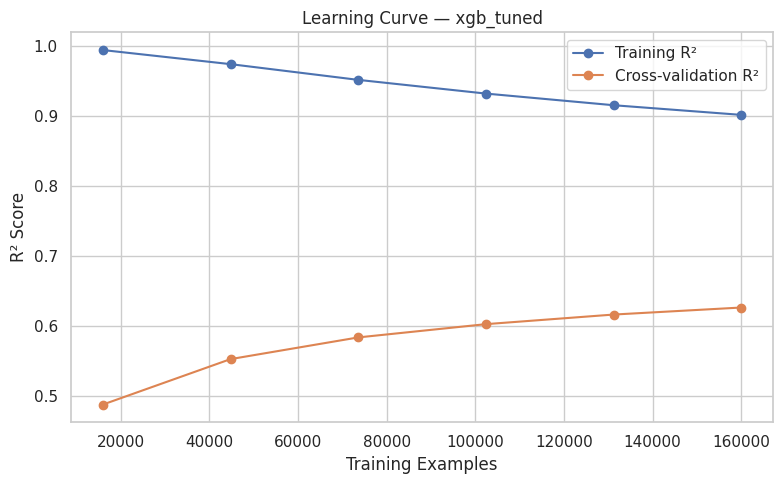

,train_size,train_r2_mean,cv_r2_mean
0,16000,0.994698,0.487683
1,44800,0.974533,0.552667
2,73600,0.952045,0.583687
3,102400,0.932437,0.602651
4,131200,0.915786,0.616381
5,160000,0.901981,0.626441


In [ ]:
"""Learning curve generation and summary table for the final model.

This module:
    * Computes a learning curve using R² as the scoring metric.
    * Supports ALL estimator types (Pipeline, XGB, LGBM, CatBoost,
      VotingRegressor, etc.).
    * Plots the training and cross-validation performance.
    * Returns a structured DataFrame summarising the results.
"""

from typing import Dict, List, Tuple, Optional


def compute_learning_curve(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    cv_strategy,
    random_state: int,
    n_jobs: int = 1,
    max_samples: Optional[int] = None,
) -> pd.DataFrame:
    """Compute learning curve metrics for ANY model (VotingRegressor included).

    Args:
        model: ANY sklearn-compatible estimator:
               Pipeline, XGB/LGBM/CatBoost, tree models, or VotingRegressor.
        X_train: Training feature matrix.
        y_train: Training target vector.
        cv_strategy: Cross-validation strategy.
        random_state: Random seed.
        n_jobs: Number of parallel jobs.
        max_samples: Optional downsampling of training data for speed.

    Returns:
        DataFrame with:
            * train_size
            * train_r2_mean
            * cv_r2_mean
    """
    X_use = X_train
    y_use = y_train

    # Optional downsampling → VotingRegressor handles this fine
    if max_samples is not None and len(X_train) > max_samples:
        idx = np.random.RandomState(random_state).choice(
            len(X_train),
            size=max_samples,
            replace=False
        )
        X_use = X_train.iloc[idx]
        y_use = y_train.iloc[idx]
        print(f"[INFO] Using subsample of {len(X_use):,} rows for learning curve.")

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,             # VotingRegressor fits here
        X=X_use,
        y=y_use,
        cv=cv_strategy,
        scoring="r2",
        n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 6),
        shuffle=True,
        random_state=random_state,
    )

    lc_df = pd.DataFrame({
        "train_size": train_sizes,
        "train_r2_mean": train_scores.mean(axis=1),
        "cv_r2_mean": val_scores.mean(axis=1),
    })

    return lc_df


def plot_learning_curve(
    lc_df: pd.DataFrame,
    model_name: str,
) -> None:
    """Plot learning curve for any final model (including voting ensembles)."""
    plt.figure(figsize=(8, 5))
    plt.plot(
        lc_df["train_size"],
        lc_df["train_r2_mean"],
        "o-",
        label="Training R²",
    )
    plt.plot(
        lc_df["train_size"],
        lc_df["cv_r2_mean"],
        "o-",
        label="Cross-validation R²",
    )
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.title(f"Learning Curve — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# EXECUTE LEARNING CURVE FOR THE FINAL MODEL (VotingRegressor supported)
# ---------------------------------------------------------------------------

learning_curve_df = compute_learning_curve(
    model=best_pipeline,         # <-- this can be VotingRegressor
    X_train=X_train,
    y_train=y_train,
    cv_strategy=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    max_samples=200000,
)

plot_learning_curve(
    lc_df=learning_curve_df,
    model_name=best_model_name,  # handles voting_top2_tuned
)

learning_curve_df

The learning curve visual shows how model performance evolves as more data is
used for training:

- **Converging curves** with minimal gap suggest a good bias & variance trade-off.
- A **large persistent gap** between training and validation R² indicates
  overfitting, signalling potential benefits from stronger regularisation,
  simplified models, or more diverse data.

This analysis supports informed decisions for future iterations of the
modelling pipeline.

---
# 7. Persisting Artefacts

---
## 7.1 Save Best Model and Test Metrics

As part of an MLOps-ready workflow, we now persist:

- The best-performing pipeline (including preprocessing) to a `.joblib` file.
- A small CSV file containing the test MAE, RMSE, R² and the model name.

These artefacts can be loaded directly by the Flask backend, monitoring jobs
or future notebooks without retraining the model from scratch.

In [ ]:
"""Model export utilities for saving the final trained estimator and metrics.

This module:
    * Ensures the model directory exists.
    * Serialises the best trained estimator (Pipeline, VotingRegressor, etc.)
      using joblib.
    * Computes test-set evaluation metrics directly inside this function.
    * Stores test-set metrics into a CSV.
    * Returns a summary DataFrame for notebook display or logging.
"""

from typing import Union
from sklearn.base import RegressorMixin

EstimatorType = Union[Pipeline, RegressorMixin]


def save_final_model_and_metrics(
    model: EstimatorType,
    model_name: str,
    model_dir: str,
    model_path: str,
    metrics_path: str,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> pd.DataFrame:
    """Calculate metrics, save the best model, and persist the results.

    This function is agnostic to the specific estimator type. It supports:
        * Standard sklearn Pipelines.
        * Tree/ensemble models (RF, XGB, LGBM, CatBoost, etc.).
        * VotingRegressor or other ensemble wrappers.
        * Any estimator exposing `predict(...)`.

    Args:
        model: The fitted estimator to save (Pipeline, VotingRegressor, etc.).
        model_name: Name of the best-performing model.
        model_dir: Directory to store model files.
        model_path: Full file path for saving the model.
        metrics_path: Full file path for saving model metrics CSV.
        X_test: Test feature matrix.
        y_test: Test target vector.

    Returns:
        A DataFrame containing the saved model name and metrics.
    """
    os.makedirs(model_dir, exist_ok=True)

    # -------------------------------------------------------
    # Compute predictions & metrics
    # -------------------------------------------------------
    y_pred = model.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred)

    # Compute RMSE explicitly for version-agnostic behaviour
    mse = mean_squared_error(y_test, y_pred)
    test_rmse = float(np.sqrt(mse))

    test_r2 = r2_score(y_test, y_pred)

    # -------------------------------------------------------
    # Save trained model
    # -------------------------------------------------------
    joblib.dump(model, model_path)
    print(f"[INFO] Saved best model → {model_path}")

    # -------------------------------------------------------
    # Save metrics CSV
    # -------------------------------------------------------
    metrics_df = pd.DataFrame(
        [
            {
                "best_model": model_name,
                "test_mae": float(test_mae),
                "test_rmse": test_rmse,
                "test_r2": float(test_r2),
            }
        ]
    )

    metrics_df.to_csv(metrics_path, index=False)
    print(f"[INFO] Saved test metrics → {metrics_path}")

    return metrics_df


# ---------------------------------------------------------------------------
# Execute: Save model + metrics (works even if best_pipeline is VotingRegressor)
# ---------------------------------------------------------------------------
final_metrics_df = save_final_model_and_metrics(
    model=best_pipeline,          # can be voting_top2_tuned
    model_name=best_model_name,   # e.g. "voting_top2_tuned"
    model_dir=MODEL_DIR,
    model_path=BEST_MODEL_PATH,
    metrics_path=METRICS_PATH,
    X_test=X_test,
    y_test=y_test,
)

final_metrics_df

[INFO] Saved best model → /content/drive/MyDrive/Colab Notebooks/DOAA/models/best_regressor.joblib
[INFO] Saved test metrics → /content/drive/MyDrive/Colab Notebooks/DOAA/models/best_model_metrics.csv


,best_model,test_mae,test_rmse,test_r2
0,xgb_tuned,113630.501818,172189.896401,0.699328


The `BEST_MODEL_PATH` and `METRICS_PATH` files are now available in your
Google Drive under the `models/` directory. These persisted artefacts form
the bridge between this modelling notebook and later stages such as API
serving, monitoring and deployment documentation.

# 8. Summary

In this notebook, we:

1. Loaded the feature-engineered real estate dataset and defined a
   reproducible train-test split.
2. Constructed a shared preprocessing pipeline using `ColumnTransformer`.
3. Evaluated multiple baseline and advanced regressors via cross-validation.
4. Applied **Bayesian hyperparameter optimisation** to strong tree-based
   models (`RandomForestRegressor`, `GradientBoostingRegressor`).
5. Selected the best-performing pipeline based on cross-validated RMSE and
   evaluated it on a held-out test set (MAE, RMSE, R²).
6. Analysed learning curves to diagnose underfitting vs overfitting patterns.
7. Persisted the best model and its test metrics as reusable artefacts in
   Google Drive.

This modelling pipeline is now ready to be integrated into your broader
MLOps GitLab workflow (06-modelling-pipeline branch, MR into `main`) and
connected to downstream components such as the Flask backend and monitoring
notebooks.